In [1]:
%run initiate.ipynb #247.536994 -48.1739027

## Import FITS Data

In [47]:
import os
import numpy as np
from astropy.io import fits
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

# --------------------------
# CONFIG
# --------------------------

bands = [
    "AKARI65", "AKARI90", "AKARI140", "AKARI160",
    "WISE1", "WISE2", "WISE3", "WISE4",
    "2MASS_h", "2MASS_j", "2MASS_k",
    "IRAC_1", "IRAC_2", "IRAC_3", "IRAC_4",
    "MIPS"
]

real_dir = "../Imported_FITS"
fake_dir = "../Imported_FITS_Fake"

# --------------------------
# DATASET
# --------------------------

class SingleBandDataset(Dataset):
    def __init__(self, real_dir, fake_dir, bands):
        self.samples = []
        for label, base_dir in [(1, real_dir), (0, fake_dir)]:
            for band_id, band in enumerate(bands):
                band_path = os.path.join(base_dir, band)
                for root, _, files in os.walk(band_path):
                    for fname in files:
                        fpath = os.path.join(root, fname)
                        try:
                            with fits.open(fpath) as hdul:
                                if hdul[0].data is None:
                                    continue  # skip empty data
                        except:
                            continue  # skip corrupted FITS
                        self.samples.append({
                            'filepath': fpath,
                            'band_id': band_id,
                            'label': label
                        })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            with fits.open(sample['filepath']) as hdul:
                data = hdul[0].data
            
                if data is None:
                    raise ValueError(f"No data in FITS file: {sample['filepath']}")
            
                data = np.nan_to_num(data)
                
                # Fix endianness here:
                data = data.byteswap().newbyteorder()
            
                if np.max(data) > 0:
                    data = data / np.max(data)
                img = torch.tensor(data).unsqueeze(0).float()
                img = F.interpolate(img.unsqueeze(0), size=(64, 64), mode='bilinear', align_corners=False).squeeze(0)
    
        except Exception as e:
            print(f"Skipping file: {sample['filepath']} | Reason: {e}")
            # Recursively pick another sample instead:
            return self.__getitem__((idx + 1) % len(self))
    
        band_id = sample['band_id']
        label = torch.tensor(sample['label']).float()
        return img, band_id, label

# --------------------------
# MODEL
# --------------------------

class YSOClassifier(nn.Module):
    def __init__(self, n_bands):
        super().__init__()
        self.band_emb = nn.Embedding(n_bands, 16)

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 + 16, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, img, band_id):
        band_vec = self.band_emb(band_id)  # ✅ correct: band_id is (batch,)
        x = self.cnn(img)
        x = torch.cat([x, band_vec], dim=1)
        return self.fc(x).squeeze(1)  # use squeeze(1) to remove output dim, keep batch dim

# --------------------------
# TRAINING
# --------------------------

batch_size = 8
epochs = 10
lr = 1e-3

dataset = SingleBandDataset(real_dir, fake_dir, bands)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = YSOClassifier(n_bands=len(bands)).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for imgs, band_ids, labels in loader:
        imgs = imgs.to(device)
        band_ids = band_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, band_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
        epoch_loss += loss.item() * imgs.size(0)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss / len(dataset):.4f}")

print("Training done!")
torch.save(model.state_dict(), "yso_classifier_simple.pth")

Epoch 1/10 - Loss: 0.6365
Epoch 2/10 - Loss: 0.6010
Epoch 3/10 - Loss: 0.5823
Epoch 4/10 - Loss: 0.5645
Epoch 5/10 - Loss: 0.5519
Epoch 6/10 - Loss: 0.5425
Epoch 7/10 - Loss: 0.5399
Epoch 8/10 - Loss: 0.5344
Epoch 9/10 - Loss: 0.5314
Epoch 10/10 - Loss: 0.5277
Training done!


In [62]:
import torch
state = torch.load("yso_classifier_simple.pth")
print(state['band_emb.weight'].shape)

torch.Size([16, 16])


## ai run

In [2]:
import os
import io
import zipfile
import requests
import time
import pandas as pd
import numpy as np
import torch
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u

# -----------------------------
# CONFIG 
# -----------------------------

band_file_map = {
    "WISE1": "wise_1",
    "WISE2": "wise_2",
    "WISE3": "wise_3",
    "WISE4": "wise_4",
    "2MASS_j": "2mass_j",
    "2MASS_h": "2mass_h",
    "2MASS_k": "2mass_k"
}

url_api = "https://irsa.ipac.caltech.edu/applications/finderchart/servlet/api"
surveys = "WISE,2MASS"

class YSOClassifier(torch.nn.Module):
    def __init__(self, n_bands):
        super().__init__()
        self.band_emb = torch.nn.Embedding(n_bands, 16)
        self.cnn = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d(1),
            torch.nn.Flatten()
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(64 + 16, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, img, band_id):
        band_vec = self.band_emb(band_id)
        x = self.cnn(img)
        x = torch.cat([x, band_vec], dim=1)
        return self.fc(x).squeeze(1)

model = YSOClassifier(n_bands=16)
model.load_state_dict(torch.load("yso_classifier_simple.pth"))
model.eval()

def fetch_fits_from_api(ra, dec, survey_name):
    params = {
        'mode': 'getImage',
        'RA': ra,
        'DEC': dec,
        'survey': surveys,
        'subsetsize': 0.25
    }
    response = requests.get(url_api, params=params)
    zip_file = zipfile.ZipFile(io.BytesIO(response.content))
    
    file_key = band_file_map.get(survey_name)
    if file_key is None:
        raise ValueError(f"No file mapping found for band '{survey_name}'")
    
    fits_name = None
    for name in zip_file.namelist():
        if file_key in name.lower():
            fits_name = name
            break
    
    if not fits_name:
        raise ValueError(f"No FITS found in ZIP for survey '{survey_name}' with file key '{file_key}'")
    
    with zip_file.open(fits_name) as f:
        hdul = fits.open(io.BytesIO(f.read()))
    
    return hdul


df = pd.read_csv("../Data/candidates.csv")[551:]

survey_bands = [
    "WISE1", "WISE2", "WISE3", "WISE4",
    "2MASS_h", "2MASS_j", "2MASS_k"
]

for idx, row in df.iterrows():
    ra = row['ra']
    dec = row['dec']
    try:
        position = SkyCoord(ra*u.deg, dec*u.deg)
        galactic_lat = position.galactic.b.deg
        if abs(galactic_lat) > 10:
            print(f"Skipping RA={ra}, DEC={dec}: |b|={galactic_lat:.2f} > 10 deg")
            continue  # skip to next source

        for band_id, band in enumerate(survey_bands):
            try:
                hdul = fetch_fits_from_api(ra, dec, band)
                data = hdul[0].data
                wcs = WCS(hdul[0].header)

                # Check if in bounds
                pix_x, pix_y = wcs.world_to_pixel(position)
                ny, nx = data.shape
                if not (0 <= pix_x < nx and 0 <= pix_y < ny):
                    print(f"Skip band={band}: RA={ra}, DEC={dec} out of image bounds")
                    continue

                cutout = Cutout2D(data, position=position, size=64, wcs=wcs)
                patch = np.nan_to_num(cutout.data)
                if np.max(patch) > 0:
                    patch = patch / np.max(patch)
                patch_tensor = torch.tensor(patch).unsqueeze(0).unsqueeze(0).float()
                band_id_tensor = torch.tensor([band_id])
                with torch.no_grad():
                    output = model(patch_tensor, band_id_tensor)
                print(f"RA={ra}, DEC={dec}, BAND={band}, Output={output.item()}")
                hdul.close()

            except Exception as e:
                print(f"Error band={band} RA={ra}, DEC={dec}: {e}")
                continue  # skip band

    except Exception as e:
        print(f"Error at RA={ra}, DEC={dec}: {e}")

    time.sleep(1)

RA=176.3936072, DEC=-64.3844676, BAND=WISE1, Output=0.31907230615615845
RA=176.3936072, DEC=-64.3844676, BAND=WISE2, Output=0.6482511162757874
RA=176.3936072, DEC=-64.3844676, BAND=WISE3, Output=0.4740634560585022
RA=176.3936072, DEC=-64.3844676, BAND=WISE4, Output=0.4106876850128174
RA=176.3936072, DEC=-64.3844676, BAND=2MASS_h, Output=0.0070498124696314335
RA=176.3936072, DEC=-64.3844676, BAND=2MASS_j, Output=0.011604213155806065
RA=176.3936072, DEC=-64.3844676, BAND=2MASS_k, Output=0.015200336463749409
RA=174.8076731, DEC=-64.1850817, BAND=WISE1, Output=0.18260332942008972
RA=174.8076731, DEC=-64.1850817, BAND=WISE2, Output=0.7116480469703674
RA=174.8076731, DEC=-64.1850817, BAND=WISE3, Output=0.47607019543647766
RA=174.8076731, DEC=-64.1850817, BAND=WISE4, Output=0.4105413556098938
RA=174.8076731, DEC=-64.1850817, BAND=2MASS_h, Output=0.01201910525560379
RA=174.8076731, DEC=-64.1850817, BAND=2MASS_j, Output=0.03009379468858242
RA=174.8076731, DEC=-64.1850817, BAND=2MASS_k, Output=0

KeyboardInterrupt: 

## Next

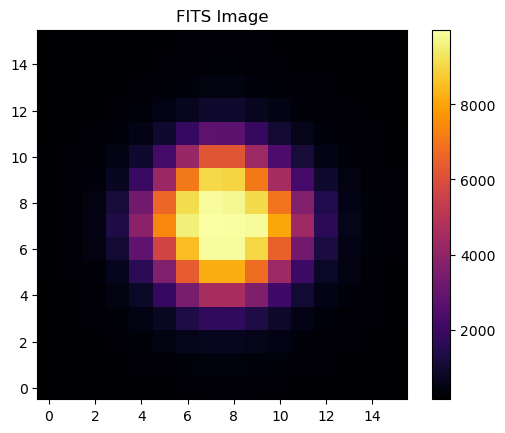

In [23]:
from astropy.io import fits
import matplotlib.pyplot as plt

hdulist = fits.open('../Imported_FITS_Fake/2MASS_j/20250614_174214_fc_317.585731-53.703973_2mass_j.fits')

image_data = hdulist[0].data

plt.imshow(image_data, cmap='inferno', origin='lower')
plt.colorbar()
plt.title('FITS Image')
plt.show()

In [ ]:
import time

url_api = "https://irsa.ipac.caltech.edu/applications/finderchart/servlet/api"
sources= []
fake_data2 = pd.read_csv('../Data/c_star.csv')

for _, row in fake_data2.iterrows():
    sources.append({'ra': row['ra'], 'dec': row['dec']})

surveys = "AKARI,WISE,2MASS,SEIP"

base_output = '../Imported_FITS_Fake'

output_folders = {
    'AKARI65': os.path.join(base_output, 'AKARI65'),
    'AKARI160': os.path.join(base_output, 'AKARI160'),
    'AKARI140': os.path.join(base_output, 'AKARI140'),
    'AKARI90': os.path.join(base_output, 'AKARI90'),

    'WISE1': os.path.join(base_output, 'WISE1'),
    'WISE2': os.path.join(base_output, 'WISE2'),
    'WISE3': os.path.join(base_output, 'WISE3'),
    'WISE4': os.path.join(base_output, 'WISE4'),
    
    '2MASS_h': os.path.join(base_output, '2MASS_h'),
    '2MASS_j': os.path.join(base_output, '2MASS_j'),
    '2MASS_k': os.path.join(base_output, '2MASS_k'),

    'IRAC_1': os.path.join(base_output, 'IRAC_1'),
    'IRAC_2': os.path.join(base_output, 'IRAC_2'),
    'IRAC_3': os.path.join(base_output, 'IRAC_3'),
    'IRAC_4': os.path.join(base_output, 'IRAC_4'),
    'MIPS': os.path.join(base_output, 'MIPS')
}

for folder in output_folders.values():
    os.makedirs(folder, exist_ok=True)

counter = 0

for source in sources[:50]:
    counter = counter + 1
    params= {
        'mode': 'getImage',
        'RA': f"{source['ra']}",
        'DEC': f"{source['dec']}",
        'survey': surveys,
        'subsetsize': .25,
    }
    
    response = requests.get(url_api, params=params)

    temp_folder = os.path.join(base_output, f"temp_{source['ra']}_{source['dec']}")
    os.makedirs(temp_folder, exist_ok=True)

    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_data:
        zip_data.extractall(temp_folder)

    for fname in os.listdir(temp_folder):
        # Check which survey this file belongs to by looking for survey name in filename
        fname_upper = fname.upper()
        dest_folder = None
        
        if 'AKARI' in fname_upper:
            if '(65)' in fname_upper:
                dest_folder = output_folders['AKARI65']
            elif '(160)' in fname_upper:
                dest_folder = output_folders['AKARI160']
            elif '(140)' in fname_upper:
                dest_folder = output_folders['AKARI140']
            elif '(90)' in fname_upper:
                dest_folder = output_folders['AKARI90']

        if 'WISE' in fname_upper:
            if 'W1' in fname_upper or 'WISE_1' in fname_upper:
                dest_folder = output_folders['WISE1']
            elif 'WISE_2' in fname_upper:
                dest_folder = output_folders['WISE2']
            elif 'WISE_3' in fname_upper:
                dest_folder = output_folders['WISE3']
            elif 'WISE_4' in fname_upper:
                dest_folder = output_folders['WISE4']
        
        elif 'SPITZER' in fname_upper:
            if '_SEIPIRAC1' in fname_upper:
                dest_folder = output_folders['IRAC_1']
            elif '_SEIPIRAC2' in fname_upper:
                dest_folder = output_folders['IRAC_2']
            elif '_SEIPIRAC3' in fname_upper:
                dest_folder = output_folders['IRAC_3']
            elif '_SEIPIRAC4' in fname_upper:
                dest_folder = output_folders['IRAC_4']
            elif '_SEIPMIPS' in fname_upper:
                dest_folder = output_folders['MIPS']

        elif '2MASS' in fname_upper or '2 MASS' in fname_upper:
            if '_H' in fname_upper:
                dest_folder = output_folders['2MASS_h']
            elif '_J' in fname_upper:
                dest_folder = output_folders['2MASS_j']
            elif '_K' in fname_upper:
                dest_folder = output_folders['2MASS_k']
        
        if dest_folder:
            timestamp_tag = time.strftime("%Y%m%d_%H%M%S")
            src_path = os.path.join(temp_folder, fname)
            dst_path = os.path.join(dest_folder, f"{timestamp_tag}_{fname}")
            shutil.move(src_path, dst_path)
        else:
            print(f"WARNING: File {fname} does not match any known survey, skipping.")
    # Remove temp folder once done
    shutil.rmtree(temp_folder)
    print(f"Processed source RA={source['ra']}, DEC={source['dec']}" + ' #' + str(counter))